## 实验6 MSTAR图像分类-使用卷积网络

### 读取图像形式的MSTAR数据
#划分为train/test  
#对数据进行归一化，即0-1之间，数据要变成float类型  
#把数据顺序打乱  
#注：若训练慢，可以减少训练图像数量

In [1]:
import torch
import numpy as np
import os
from PIL import Image

# 数据集路径
data_root = 'D:\DeepLearning\mstar'
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'validation')

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
    for cls in class_names:
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(cls_dir, fname)
                img = Image.open(img_path).convert('L')
                img_array = np.array(img)
                images.append(img_array)
                labels.append(class_to_idx[cls])
    images = np.stack(images, axis=0)
    images = images[:, np.newaxis, :, :]   # (N, 1, H, W)
    labels = np.array(labels)
    return images, labels

# 加载训练集和验证集
train_img, train_lb = load_images_from_folder(train_dir)
val_img,   val_lb   = load_images_from_folder(val_dir)

print("总数据量：训练集 {} 张，验证集 {} 张".format(train_img.shape[0], val_img.shape[0]))

if train_lb.min() == 1:
    train_lb = train_lb - 1
    val_lb   = val_lb - 1

min_train_num = 2800
total_train = train_img.shape[0]
random_indices = np.random.choice(total_train, size=min(min_train_num, total_train), replace=False)
train_img = train_img[random_indices]
train_lb  = train_lb[random_indices]

# 归一化到 [0,1]
train_img = train_img / 255.0
val_img   = val_img   / 255.0

# 独热编码
num_classes = len(np.unique(train_lb))
one_hot_train_lb = np.eye(num_classes)[train_lb]
one_hot_val_lb   = np.eye(num_classes)[val_lb]

# 打印信息
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape, '热编码训练集标签格式为:', one_hot_train_lb.shape)
print('验证集图像格式为:', val_img.shape,   '验证集标签格式为:', val_lb.shape,   '热编码验证集标签格式为:', one_hot_val_lb.shape)

# 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

总数据量：训练集 2747 张，验证集 2425 张
训练集图像格式为: (2747, 1, 128, 128) 训练集标签格式为: (2747,) 热编码训练集标签格式为: (2747, 10)
验证集图像格式为: (2425, 1, 128, 128) 验证集标签格式为: (2425,) 热编码验证集标签格式为: (2425, 10)
Using device: cuda


### 数据增强
#from torchvision.transforms  包含的数据增强进行数据扩充。


#参考下面的例子  

In [2]:
from torchvision.transforms import v2
import torch

train_img_t = torch.tensor(train_img, dtype=torch.float32)
train_lb_t  = torch.tensor(train_lb,  dtype=torch.long)
val_img_t   = torch.tensor(val_img,   dtype=torch.float32)
val_lb_t    = torch.tensor(val_lb,    dtype=torch.long)

transform_aug = v2.Compose([
    v2.RandomRotation(degrees=(-15, 15)),
    # v2.RandomVerticalFlip(p=0.5),
    # v2.RandomHorizontalFlip(p=0.5),
])

augmented_img = transform_aug(train_img_t)
augmented_lb  = train_lb_t.clone()

train_img_aug = torch.cat([train_img_t, augmented_img], dim=0)
train_lb_aug  = torch.cat([train_lb_t,  augmented_lb],  dim=0)

### 题目1：定义并训练卷积神经网络（基于Pytorch）
#利用BN层、超参数调整等方式，提升分类精度。   

#### 定义网络  

In [3]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self, input_channels=1, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, 3, stride=1, padding=1) # 128x128
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)             # 64x64
        self.conv3 = nn.Conv2d(64, 128, 3, stride=1, padding=1)            # 64x64
        self.conv4 = nn.Conv2d(128, 128, 3, stride=2, padding=1)           # 32x32
        self.conv5 = nn.Conv2d(128, 256, 3, stride=1, padding=1)           # 32x32
        self.conv6 = nn.Conv2d(256, 256, 3, stride=2, padding=1)           # 16x16
        
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(128)
        self.bn5 = nn.BatchNorm2d(256)
        self.bn6 = nn.BatchNorm2d(256)
        
        self.relu = nn.ReLU()
        
        self.fc1 = nn.Linear(256 * 16 * 16, 1024)
        self.dropout1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(1024, 128)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.relu(self.bn6(self.conv6(x)))
        
        x = x.view(x.size(0), -1)
        x = self.dropout1(self.relu(self.fc1(x)))
        x = self.dropout2(self.relu(self.fc2(x)))
        x = self.fc3(x)
        
        return x


#### 训练\测试网络

In [4]:
import torch
from torch.utils.data import DataLoader, TensorDataset

batch_size = 180
epochs = 15
learning_rate = 0.0005

# 创建 DataLoader
train_dataset = TensorDataset(train_img_aug, train_lb_aug)
val_dataset = TensorDataset(val_img_t, val_lb_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 模型、损失函数、优化器
model = NeuralNetwork(input_channels=1, num_classes=num_classes)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
loss_fn = loss_fn.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 记录指标
loss_his = []
acc_his = []
val_loss_his = []
val_acc_his = []

model.train()
for epoch in range(epochs):
    train_loss = 0.0
    train_correct = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(pred, 1)
        total_train += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()
    
    avg_train_loss = train_loss / total_train
    train_acc = train_correct / total_train
    loss_his.append(avg_train_loss)
    acc_his.append(train_acc)
  
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            
            pred_val = model(X_val)
            loss_val = loss_fn(pred_val, y_val)
            val_loss += loss_val.item() * X_val.size(0)
            _, pred_label = torch.max(pred_val, 1)
            total_val += y_val.size(0)
            val_correct += (pred_label == y_val).sum().item()
    
    avg_val_loss = val_loss / total_val
    val_acc = val_correct / total_val
    val_loss_his.append(avg_val_loss)
    val_acc_his.append(val_acc)
    
    model.train()
    
    print(f"Epoch {epoch+1:2d}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

Epoch  1/15, Train Loss: 2.2117, Train Acc: 21.99%, Val Loss: 1.9012, Val Acc: 29.53%
Epoch  2/15, Train Loss: 1.2581, Train Acc: 52.60%, Val Loss: 1.0498, Val Acc: 60.16%
Epoch  3/15, Train Loss: 0.6825, Train Acc: 74.44%, Val Loss: 0.5994, Val Acc: 80.74%
Epoch  4/15, Train Loss: 0.4008, Train Acc: 85.46%, Val Loss: 0.3403, Val Acc: 87.92%
Epoch  5/15, Train Loss: 0.2334, Train Acc: 92.03%, Val Loss: 0.2612, Val Acc: 91.75%
Epoch  6/15, Train Loss: 0.1551, Train Acc: 95.05%, Val Loss: 0.3264, Val Acc: 91.51%
Epoch  7/15, Train Loss: 0.1067, Train Acc: 96.38%, Val Loss: 0.1641, Val Acc: 95.18%
Epoch  8/15, Train Loss: 0.1032, Train Acc: 97.00%, Val Loss: 0.2040, Val Acc: 94.14%
Epoch  9/15, Train Loss: 0.0720, Train Acc: 97.67%, Val Loss: 0.0818, Val Acc: 97.48%
Epoch 10/15, Train Loss: 0.0546, Train Acc: 98.20%, Val Loss: 0.1456, Val Acc: 95.55%
Epoch 11/15, Train Loss: 0.0340, Train Acc: 99.04%, Val Loss: 0.2286, Val Acc: 94.06%
Epoch 12/15, Train Loss: 0.0244, Train Acc: 99.29%, Va

#### 实验结果与分析
#e.g.哪些策略提升了分类精度  

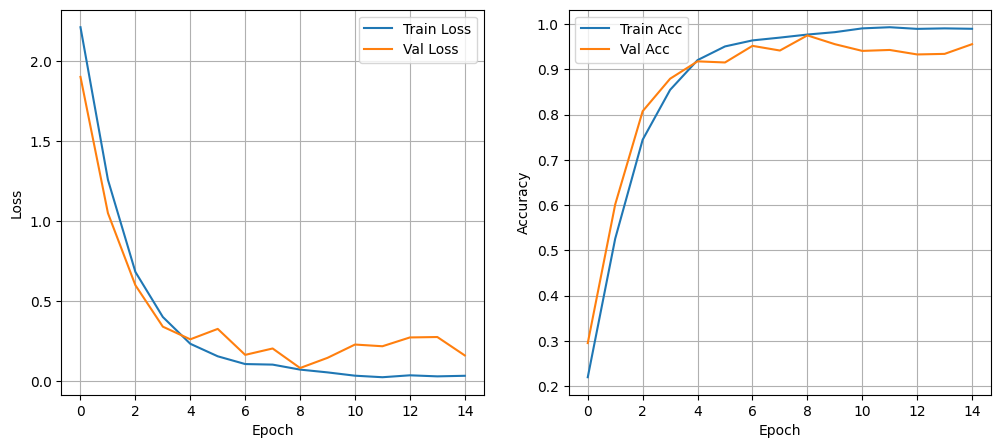

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss_his, label='Train Loss')
plt.plot(val_loss_his, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(acc_his, label='Train Acc')
plt.plot(val_acc_his, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#### 总结

### 评分标准：
#测试精度越高，得分越高  
#只能提交PDF  
#代码尽量简洁高效，不包含实验题目无关的函数、代码  
#按照题目大纲编写程序  
#课上能够完成加分   
#实验结果完整、格式规范   
#图文并茂、实验结果分析有自己的想法   
##### 